In [1]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split

print("TensorFlow:", tf.__version__)
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

2025-11-26 00:59:35.289268: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764098975.353984   34621 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764098975.372742   34621 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1764098975.452356   34621 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1764098975.452377   34621 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1764098975.452379   34621 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
Num GPUs Available:  1


In [2]:
df = pd.read_csv("dataset/train.csv")
df

,sample_id,image_path,Sampling_Date,State,Species,Pre_GSHH_NDVI,Height_Ave_cm,target_name,target
0,ID1011485656__Dry_Clover_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Clover_g,0.0000
1,ID1011485656__Dry_Dead_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Dead_g,31.9984
2,ID1011485656__Dry_Green_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Green_g,16.2751
3,ID1011485656__Dry_Total_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Total_g,48.2735
4,ID1011485656__GDM_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,GDM_g,16.2750
...,...,...,...,...,...,...,...,...,...
1780,ID983582017__Dry_Clover_g,train/ID983582017.jpg,2015/9/1,WA,Ryegrass,0.64,9.0000,Dry_Clover_g,0.0000
1781,ID983582017__Dry_Dead_g,train/ID983582017.jpg,2015/9/1,WA,Ryegrass,0.64,9.0000,Dry_Dead_g,0.0000
1782,ID983582017__Dry_Green_g,train/ID983582017.jpg,2015/9/1,WA,Ryegrass,0.64,9.0000,Dry_Green_g,40.9400
1783,ID983582017__Dry_Total_g,train/ID983582017.jpg,2015/9/1,WA,Ryegrass,0.64,9.0000,Dry_Total_g,40.9400


In [3]:
# 2. Pivot Data to Wide Format (One row per image, 5 target columns)
# We need to pivot on 'image_path' (or sample_id) and 'target_name'
pivot_df = df.pivot_table(index='image_path', columns='target_name', values='target').reset_index()
pivot_df

target_name,image_path,Dry_Clover_g,Dry_Dead_g,Dry_Green_g,Dry_Total_g,GDM_g
0,train/ID1011485656.jpg,0.0000,31.9984,16.2751,48.2735,16.2750
1,train/ID1012260530.jpg,0.0000,0.0000,7.6000,7.6000,7.6000
2,train/ID1025234388.jpg,6.0500,0.0000,0.0000,6.0500,6.0500
3,train/ID1028611175.jpg,0.0000,30.9703,24.2376,55.2079,24.2376
4,train/ID1035947949.jpg,0.4343,23.2239,10.5261,34.1844,10.9605
...,...,...,...,...,...,...
352,train/ID975115267.jpg,40.0300,0.0000,0.8000,40.8300,40.8300
353,train/ID978026131.jpg,24.6445,4.1948,12.0601,40.8994,36.7046
354,train/ID980538882.jpg,0.0000,1.1457,91.6543,92.8000,91.6543
355,train/ID980878870.jpg,32.3575,0.0000,2.0325,34.3900,34.3900


In [4]:
# Ensure columns are in a consistent order
target_cols = ['Dry_Green_g', 'Dry_Dead_g', 'Dry_Clover_g', 'GDM_g', 'Dry_Total_g']
pivot_df = pivot_df[['image_path'] + target_cols]
pivot_df

# filling NaNs if any, Nahi h toh comment kar dia filhal
# pivot_df[target_cols] = pivot_df[target_cols].fillna(0.0)

# print("Pivoted Shape:", pivot_df.shape)
display(pivot_df.head())

target_name,image_path,Dry_Green_g,Dry_Dead_g,Dry_Clover_g,GDM_g,Dry_Total_g
0,train/ID1011485656.jpg,16.2751,31.9984,0.0000,16.2750,48.2735
1,train/ID1012260530.jpg,7.6000,0.0000,0.0000,7.6000,7.6000
2,train/ID1025234388.jpg,0.0000,0.0000,6.0500,6.0500,6.0500
3,train/ID1028611175.jpg,24.2376,30.9703,0.0000,24.2376,55.2079
4,train/ID1035947949.jpg,10.5261,23.2239,0.4343,10.9605,34.1844


In [5]:
# 3. Split Data
train_df, val_df = train_test_split(pivot_df, test_size=0.15, random_state=42)

print("Train images:", len(train_df))
print("Val images:", len(val_df))

Train images: 303
Val images: 54


In [6]:
# 4. Create TensorFlow Dataset
IMG_SIZE = 512
BATCH_SIZE = 8

def load_image(path):
    # Expand on this function MORE (image pre-processing here)
    img = tf.io.read_file("dataset/" + path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32) / 255.0  
    return img


In [7]:
train_df.head()

target_name,image_path,Dry_Green_g,Dry_Dead_g,Dry_Clover_g,GDM_g,Dry_Total_g
346,train/ID95050718.jpg,21.3496,15.0024,2.3081,23.6576,38.6600
185,train/ID1988033238.jpg,21.1479,12.4718,4.8803,26.0282,38.5000
3,train/ID1028611175.jpg,24.2376,30.9703,0.0000,24.2376,55.2079
116,train/ID1573329652.jpg,22.2985,19.2015,0.0000,22.2985,41.5000
76,train/ID141370843.jpg,19.6636,5.6182,5.6182,25.2818,30.9000


In [8]:
len(train_df['image_path'].values)

303

In [9]:
def create_dataset(dataframe, batch_size=BATCH_SIZE, shuffle=False):
    image_paths = dataframe['image_path'].values # ONLY the path of every image 
    
    # target_cols = ['Dry_Green_g', 'Dry_Dead_g', 'Dry_Clover_g', 'GDM_g', 'Dry_Total_g'] (upar declare kar dia tha)
    targets = dataframe[target_cols].values.astype(np.float32)
    ds = tf.data.Dataset.from_tensor_slices((image_paths, targets))

    def map_func(path, target):
        return load_image(path), target
    
    ds = ds.map(map_func, num_parallel_calls=tf.data.AUTOTUNE)
    
    if shuffle:
        ds = ds.shuffle(buffer_size=1000)
        
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


In [10]:
train_ds = create_dataset(train_df, shuffle=True)
val_ds = create_dataset(val_df, shuffle=False)

# Verify shapes
for img_batch, target_batch in train_ds.take(1):
    print("Image batch shape:", img_batch.shape)
    print("Target batch shape:", target_batch.shape)
    print("Sample targets:", target_batch[0].numpy())

I0000 00:00:1764098979.076074   34621 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5369 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Image batch shape: (8, 512, 512, 3)
Target batch shape: (8, 5)
Sample targets: [57.6643 25.1357  0.     57.6643 82.8   ]


2025-11-26 00:59:41.174175: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [11]:
for image, targets in train_ds.take(1):
    print(targets)

tf.Tensor(
[[ 0.      0.     10.88   10.88   10.88  ]
 [16.2751 31.9984  0.     16.275  48.2735]
 [15.5429  3.8857  0.9714 16.5143 20.4   ]
 [ 4.1458 29.1542  0.      4.1458 33.3   ]
 [ 6.7     5.2     3.8    10.5    15.7   ]
 [45.5236  1.2764  0.     45.5236 46.8   ]
 [19.4992 14.4672  7.2336 26.7328 41.2   ]
 [30.6643 17.0357  0.     30.6643 47.7   ]], shape=(8, 5), dtype=float32)


2025-11-26 00:59:42.548517: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


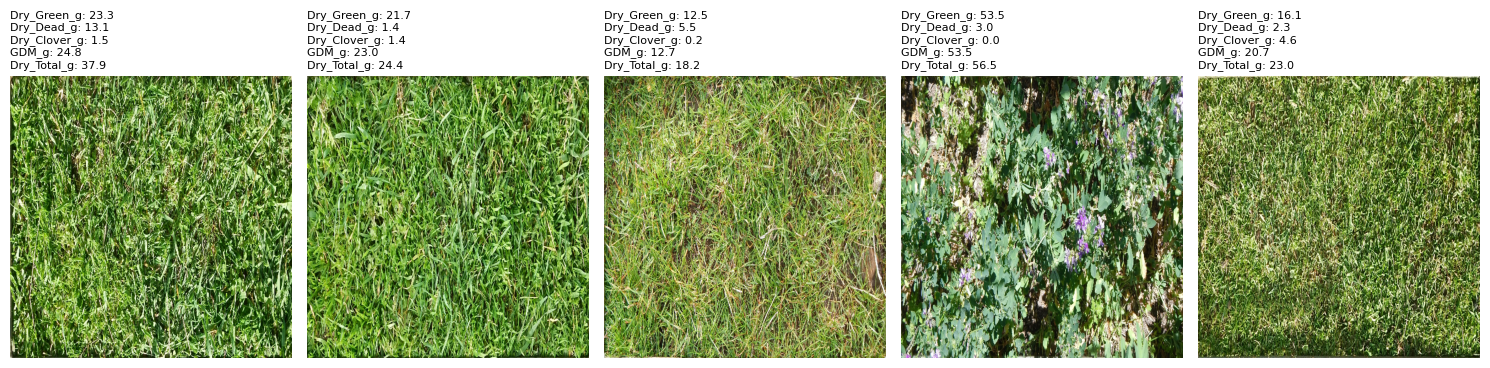

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

for images, targets in train_ds.take(1):
    for i in range(5):
        ax = plt.subplot(1, 5, i + 1)
        plt.imshow(images[i].numpy())
        
        # Create a string for the targets
        t = targets[i].numpy()
        title_str = "\n".join([f"{n}: {v:.1f}" for n, v in zip(target_cols, t)])
        
        plt.title(title_str, fontsize=8, loc='left')
        plt.axis("off")
plt.tight_layout()
plt.show()

## BUILDING THE MODEL NOW

In [13]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Conv2D, BatchNormalization, ReLU, Add,
    GlobalAveragePooling2D, Dense, Dropout, Input,
    Multiply, Reshape
)
from tensorflow.keras.models import Model


# ------------------------------------------------------------
# BASIC RESNET BLOCK (no pretrained weights)
# ------------------------------------------------------------
def resnet_block(x, filters, stride=1):
    shortcut = x

    # Conv 1
    y = Conv2D(filters, 3, strides=stride, padding="same", use_bias=False)(x)
    y = BatchNormalization()(y)
    y = ReLU()(y)

    # Conv 2
    y = Conv2D(filters, 3, strides=1, padding="same", use_bias=False)(y)
    y = BatchNormalization()(y)

    # Shortcut adjustment
    if stride != 1 or x.shape[-1] != filters:
        shortcut = Conv2D(filters, 1, strides=stride, padding="same", use_bias=False)(shortcut)
        shortcut = BatchNormalization()(shortcut)

    out = Add()([y, shortcut])
    out = ReLU()(out)
    return out


# ------------------------------------------------------------
# Squeeze–Excitation (unchanged)
# ------------------------------------------------------------
def squeeze_excitation(x, reduction=16):
    filters = x.shape[-1]
    se = GlobalAveragePooling2D()(x)
    se = Dense(filters // reduction, activation="relu")(se)
    se = Dense(filters, activation="sigmoid")(se)
    se = Reshape((1, 1, filters))(se)
    return Multiply()([x, se])


# ------------------------------------------------------------
# FINAL RESNET ARCH — SAME DIMENSIONS
# ------------------------------------------------------------
def build_improved_model(img_size=512):
    inputs = Input(shape=(img_size, img_size, 3), name="image_input")

    # Stem — exactly same stride (2)
    x = Conv2D(32, 3, strides=2, padding="same", use_bias=False)(inputs)
    x = BatchNormalization()(x)
    x = ReLU()(x)                            # -> 256×256×32

    # Stage 0 (your 32 block)
    x = resnet_block(x, 32, stride=1)        # -> 256×256×32

    # Stage 1 (64 filters, stride 2 exactly like your code)
    x = resnet_block(x, 64, stride=1)
    x = resnet_block(x, 64, stride=2)        # -> 128×128×64

    # Stage 2 (128)
    x = resnet_block(x, 128, stride=1)
    x = resnet_block(x, 128, stride=2)       # -> 64×64×128

    # Stage 3 (256)
    x = resnet_block(x, 256, stride=1)
    x = resnet_block(x, 256, stride=2)       # -> 32×32×256

    # Stage 4 (512)
    x = resnet_block(x, 512, stride=1)
    x = resnet_block(x, 512, stride=2)       # -> 16×16×512

    # SE block — unchanged
    x = squeeze_excitation(x)

    # Global pooling + head — unchanged
    x = GlobalAveragePooling2D()(x)

    x = Dense(512, activation="relu")(x)
    x = Dropout(0.25)(x)

    x = Dense(256, activation="relu")(x)
    x = Dropout(0.15)(x)

    x = Dense(128, activation="relu")(x)
    
    outputs = Dense(5)(x)

    model = Model(inputs, outputs)
    return model


model = build_improved_model(IMG_SIZE)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        864 │ image_input[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      9,216 │ re_lu[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 256, 256,  │      9,216 │ re_lu_1[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │ re_lu[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 256, 256,  │          0 │ add[0][0]         │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 256, 256,  │     18,432 │ re_lu_2[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 256, 256,  │     36,864 │ re_lu_3[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 256, 256,  │      2,048 │ re_lu_2[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_4[0][0]  

 Total params: 11,992,837 (45.75 MB)

 Trainable params: 11,981,125 (45.70 MB)

 Non-trainable params: 11,712 (45.75 KB)

In [14]:
# model arch 
from tensorflow.keras.utils import plot_model
from IPython.display import Image, display

# plot_model(model, to_file="/home/vector/project/CSIRO---Image2Biomass-Prediction/model.png", show_shapes=True, show_layer_names=True)

# Image is wayy too long, working on notebook becomes difficult

# we will assign weights to the output parameters

In [15]:
import tensorflow.keras.backend as K

def weighted_r2(y_true, y_pred):
    # Weights for the 5 biomass components
    # Dry_Green_g, Dry_Dead_g, Dry_Clover_g, GDM_g, Dry_Total_g
    weights = tf.constant([0.1, 0.1, 0.1, 0.2, 0.5], dtype=tf.float32)
    
    # Total Sum of Squares (TSS)
    mean_y_true = K.mean(y_true, axis=0)
    tss = K.sum(K.square(y_true - mean_y_true), axis=0)
    
    # Residual Sum of Squares (RSS)
    rss = K.sum(K.square(y_true - y_pred), axis=0)
    
    # R2 for each component: 1 - (RSS / (TSS + epsilon))
    # Adding epsilon to avoid division by zero
    r2_scores = 1 - (rss / (tss + K.epsilon()))
    
    # Weighted Average R2
    weighted_r2_score = K.sum(r2_scores * weights)
    
    return weighted_r2_score

# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='mse',
    metrics=['mae','accuracy', weighted_r2]
)


In [ ]:
# Callbacks
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'best_model.keras', 
    monitor='val_weighted_r2', 
    mode='max', 
    save_best_only=True, 
    verbose=1
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_weighted_r2', 
    mode='max', 
    patience=10, 
    restore_best_weights=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_weighted_r2', 
    mode='max', 
    factor=0.5, 
    patience=5, 
    min_lr=1e-6,
    verbose=1
)

# Train
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=70,
    callbacks=[checkpoint, reduce_lr]
)


Epoch 1/70


38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 0.8621 - loss: 735.4163 - mae: 17.3734 - weighted_r2: -1.2536
Epoch 1: val_weighted_r2 improved from None to -0.67529, saving model to best_model.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 16s 248ms/step - accuracy: 0.8944 - loss: 653.0455 - mae: 16.3177 - weighted_r2: -0.8681 - val_accuracy: 0.8519 - val_loss: 636.7692 - val_mae: 16.8484 - val_weighted_r2: -0.6753 - learning_rate: 1.0000e-04
Epoch 2/70


In [ ]:
import matplotlib.pyplot as plt

def plot_history(history):
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    mae = history.history['mae']
    val_mae = history.history['val_mae']
    r2 = history.history['weighted_r2']
    val_r2 = history.history['val_weighted_r2']
    
    epochs = range(1, len(loss) + 1)
    
    plt.figure(figsize=(18, 5))
    
    # Plot Loss
    plt.subplot(1, 3, 1)
    plt.plot(epochs, loss, 'bo-', label='Training Loss')
    plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
    plt.title('Training and Validation Loss (MSE)')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    
    # Plot MAE
    plt.subplot(1, 3, 2)
    plt.plot(epochs, mae, 'bo-', label='Training MAE')
    plt.plot(epochs, val_mae, 'ro-', label='Validation MAE')
    plt.title('Training and Validation MAE')
    plt.xlabel('Epochs')
    plt.ylabel('MAE')
    plt.legend()
    
    # Plot Weighted R2
    plt.subplot(1, 3, 3)
    plt.plot(epochs, r2, 'bo-', label='Training Weighted R2')
    plt.plot(epochs, val_r2, 'ro-', label='Validation Weighted R2')
    plt.title('Training and Validation Weighted R2')
    plt.xlabel('Epochs')
    plt.ylabel('Weighted R2')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

plot_history(history)


In [ ]:
model.save("model7_v2.h5")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def evaluate_and_visualize(model, val_ds, num_samples=5):
    # 1. Get all predictions and true values
    all_images = []
    all_targets = []
    all_preds = []
    
    print("Generating predictions for validation set...")
    # Unbatch the dataset to process all samples
    for images, targets in val_ds:
        preds = model.predict(images, verbose=0)
        all_images.append(images.numpy())
        all_targets.append(targets.numpy())
        all_preds.append(preds)
        
    # Concatenate batches
    all_images = np.concatenate(all_images, axis=0)
    all_targets = np.concatenate(all_targets, axis=0)
    all_preds = np.concatenate(all_preds, axis=0)
    
    # 2. Calculate Overall Weighted R2
    weights = np.array([0.1, 0.1, 0.1, 0.2, 0.5])
    
    mean_true = np.mean(all_targets, axis=0)
    tss = np.sum((all_targets - mean_true)**2, axis=0)
    rss = np.sum((all_targets - all_preds)**2, axis=0)
    
    # Avoid division by zero
    r2_scores = 1 - (rss / (tss + 1e-7))
    weighted_r2 = np.sum(r2_scores * weights)
    
    print(f"\nOverall Weighted R2 Score: {weighted_r2:.4f}")
    print(f"Component R2 Scores:")
    target_names = ['Dry_Green_g', 'Dry_Dead_g', 'Dry_Clover_g', 'GDM_g', 'Dry_Total_g']
    for name, score in zip(target_names, r2_scores):
        print(f"  {name:<15}: {score:.4f}")
        
    # 3. Visualize Samples
    print(f"\nVisualizing {num_samples} random samples...")
    indices = np.random.choice(len(all_images), num_samples, replace=False)
    
    for idx in indices:
        img = all_images[idx]
        true = all_targets[idx]
        pred = all_preds[idx]
        
        plt.figure(figsize=(12, 4))
        
        # Image
        plt.subplot(1, 2, 1)
        plt.imshow(img)
        plt.axis('off')
        plt.title("Input Image")
        
        # Table of values
        plt.subplot(1, 2, 2)
        plt.axis('off')
        
        # Header
        text_str = f"{'Component':<15} | {'True':>6} | {'Pred':>6} | {'Diff':>6}\n"
        text_str += "-"*45 + "\n"
        
        # Rows
        for i, name in enumerate(target_names):
            diff = pred[i] - true[i]
            text_str += f"{name:<15} | {true[i]:6.1f} | {pred[i]:6.1f} | {diff:6.1f}\n"
            
        plt.text(0, 0.5, text_str, fontsize=12, family='monospace', va='center')
        plt.tight_layout()
        plt.show()

# Run evaluation
evaluate_and_visualize(model, val_ds)


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import os

def generate_submission(model):
    print("Loading test data...")
    test_df = pd.read_csv("dataset/test.csv")
    
    # Get unique images to predict on
    unique_images = test_df['image_path'].unique()
    print(f"Found {len(unique_images)} unique test images.")
    
    # Create Dataset
    def load_image(path):
        # Check if path exists
        full_path = "dataset/" + path
        img = tf.io.read_file(full_path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
        img = tf.cast(img, tf.float32) / 255.0
        return img

    test_ds = tf.data.Dataset.from_tensor_slices(unique_images)
    test_ds = test_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    
    print("Predicting...")
    # Predict
    predictions = model.predict(test_ds, verbose=1)
    
    # Map predictions to image paths
    # predictions shape: (N_images, 5)
    # Target order: ['Dry_Green_g', 'Dry_Dead_g', 'Dry_Clover_g', 'GDM_g', 'Dry_Total_g']
    target_cols = ['Dry_Green_g', 'Dry_Dead_g', 'Dry_Clover_g', 'GDM_g', 'Dry_Total_g']
    
    # Create a lookup dictionary: image_path -> {target_name: value}
    pred_dict = {}
    for img_path, pred_row in zip(unique_images, predictions):
        pred_dict[img_path] = {col: val for col, val in zip(target_cols, pred_row)}
        
    print("Formatting submission...")
    # Create submission rows
    submission_rows = []
    for index, row in test_df.iterrows():
        img_path = row['image_path']
        target_name = row['target_name']
        sample_id = row['sample_id']
        
        # Get prediction
        if img_path in pred_dict:
            pred_value = pred_dict[img_path][target_name]
        else:
            # Fallback if something went wrong (shouldn't happen)
            pred_value = 0.0
        
        # Ensure non-negative (biomass can't be negative)
        pred_value = max(0.0, pred_value)
        
        submission_rows.append({'sample_id': sample_id, 'target': pred_value})
        
    submission_df = pd.DataFrame(submission_rows)
    
    # Save to CSV
    output_file = "submission.csv"
    submission_df.to_csv(output_file, index=False)
    print(f"Saved submission to {output_file}")
    
    # Print the content for user to copy if needed
    print("\n" + "="*20 + " SUBMISSION CSV CONTENT " + "="*20)
    print(submission_df.to_csv(index=False))
    print("="*64)

# Run generation
generate_submission(model)
